In [1]:
%pip install pandas matplotlib seaborn numpy scipy scikit-learn ipywidgets


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Dados e Distribuicoes Amostrais

Um equivoco comum com a chegada do Big Data (Manipulacao de grandes bases de dados (amostras gigantes)) é pensar quer a amostragem nao é mais necessária. Mas na verdade com o crescimento de dados de varios tipos e relevancias, a amostragem se torna uma ferramente muito importante para se trabalhar de forma eficiente com uma variedade de dados e reduzir ao maximo vieses desses dados. Modelos preditivos mesmo no big data sao desenvolvidos com amostras (que tem que ser bem coletadas) e além disso, varios testes sao feitos em amostras como testes A/B em paginas web.

<img src="images_statistics/popxsample.png" width="600" style="display:block; margin:auto;">

Essa imagem mostra os conceitos que vai ser discutido aqui: Dados (populacao) e Distribuicao de Amostragem (Amostras). A esquerda temos a populacao que segue alguma distribuicao que normalmente é desconhecida. Temos a direita entao as amostras que tem uma distribuicao empirica conhecida mas que nao necessáriamente é a da populacao. As amostras sao conseguidas através da populacao pelo processo de amostragem. Estatisticos focam muito na parte esquerda usando teoria e suposicoes sobre a populacao.

Em geral, cientistas de dados nao tem que se precoupar com a natureza teórica da populacao e ao inves disso deveria focar nos procedimentos de amostragem e nos dados das amostras que foram coletados. Porém existem algumas execoes em que podemos usar o modelo probabilístico conhecido como por exemplo em situacoes em que os dados sao gerados de um processo que pode ser modelado em uma distribuicao de binomial lancamentos de moedas, comprar ou nao comprar, fraude ou nao fraude e clicar ou nao clicar... todos sao exemplos reais que seguem a distribuicao de binomial pois sao essencialmente binários (mas nao todo evento binário é essencialmente binomial pois binomial assume independencia e mesma probabilidade) mas com probabilidades diferentes. Nesses casos podemos ganhar vantagens com conhecimento da populacao por exemplos sabemos que o valor esperado de um processo binomial é np e variancia np(1-p).

## Amostragem aleatória e vies de amostra

Amostra é um subconjunto de um dataset maior chamado Population, um grande conjunto de dados definido (que pode ser teórico ou imaginário). A qualidade dos dados geralmente importa mais que a quantidade quando esta fazendo uma estimativa ou modelo. A qualidade envolve completude, limpeza e representatividade. Em uma das eleicoes dos EUA (Alf landon vs Franklin) uma revista famosa (literary digest) e cara enviou um questionario sobre quem iria votar para seus 10 milhoes de assinantes e teve retorno de 2.4 milhoes de respostas. Ao mesmo tempo um pesquisador realizou pesquisas e obteve uma amostra de 2000 sobre os votos. Nessa epoca Franklin tinha uma proposta mais social e menos elitista que Alf. A amostra da revista veio principalmente das pessoas que podiam pagar a revista (que nao era barata) , ou seja, de quem tinha uma renda maior e previu com muita confianca que Alf ganharia porém na realidade quem ganhou foi Franklin. Isso é um exemplo de vies de amostragem significante do tipo nao aleatorio. O erro nao é aleatório pois dificilmente (na verdade é ate esperado) uma amostra ira representar fielmente sua populacao, vies de amostragem acontece quando essa diferenca é significante.

- Random Sampling: é um processo de amostragem em que cada elemento da populacao tem probabilidade igual de ser selecionada. O conjunto resultado é chamado de amostra simples aleatoria e a amostragem pode ser com reposicao ou sem reposicao: 
  - Com reposicao, após recolher uma amostra as amostras sao colocadas novamete na populacao e podem ser sorteadas novamente e um nova amostra. 
  - Sem reposicao, apos serem sorteadas elas nao voltam para populacao e nao podem mais ser sorteadas no futuro

- Self-Selection Sampling Bias:
As avaliacoes de restaurantes, hoteis e etc sao inclinados a ter vies pois as pessoas que fazem as avaliacoes nao sao aleatoriamente escolhidas, elas mesmas decidem avaliar ou nao. Pessoas geralmente nao gostam de ficar avaliando coisas entao quem é motivado a avaliar sao pessoas que ou tiveram uma experiencia ruim ou tem alguma ligacao com o estabelecimento (funcionarios) ou sao pessoas bem diferentes daquelas que nao gostam de escrever avaliacoes. Mas repare que enquanto essas avaliacoes sao enviesadas e ruins para definir alguma verdade (restaurante bom ou ruim), elas ainda sao uteis para se comparar restaurantes umas vez que ambas tiveram o mesmo tipo de vies e podem ser comparadas.

- Statistical Bias (vies estatistico)
O erro estatistico é qualquer tipo de erro fruto de erro de medicao ou erro de amostragem. É importante distinguir erros aleatório e erros de vies, erros aleatórios sao gerados aleatoriamente e portanto nao irao tender a nenhuma direcao ou padrao. Erros por vies tendem a tender para alguma direcao ou padrao especifico. (Por exemplo vies de genero é quando o modelo tende a escolher um genero especifico em cituacoes que nao deveria). O viés vem em diferentes formas e pode ou nao ser observavel. Quando o resultado sugere viés por alguma referencia entao isso significa que importantes variaveis foram deixadas de lado ou modelo mal construido.

<img src="images_statistics/erro_vies.png" width="600" style="display:block; margin:auto;">

- Stratified Sampling (amostragem estratificada):
Hoje existem varias maneiras de se alcancar amostras representativas da populacao mas em todas as maneiras, a amostragem aleatória esta presente: A amostragem aleatoria nem sempre é facil mas chave do sucesso é definir bem a populacao que queremos estudar... por exemplo imagine que queremos estudar o perfil representativo de clientes de uma loja. Primeiro é necessário fazer algumas definicoes como quem sao os clientes ? vamos incluir todos os clientes do passado ou os mais comuns ? incluimos devolucoes ?. Depois é necessário definir o processo de amostragem, vamos coletar 100 clientes aleatórios ? Quando a amostragem envolve um fluxo (como de clientes em um site ou aplicativo) nem sempre o cliente que acessou fim de semana é o mesmo tipo do que acessou quarta de noite(precisamos dividir a populacoa em grupos). Suponha que temos uma populacao com P(negro)=0.15, P(hispanicos)=0.20 e P(brancos)=0.65 se coletarmos 100 aleatoriamente teremos no melhor caso 15 negros e 20 hispanicos. O problema é que talvez é que o tamanho da amostra 15 seja muito pequeno para estimar algo dos negros. Na amostragem estratificada nos dividimos a populacao em stratas (grupos) e amostamos aleatoriamente de cada grupo, por exemplo tempo 100 negros, 100 brancos e 100 hispanicos, assim teriamos amostras representativas de cada grupo. Entratanto outro problema aparece que é o que nao estamos mais representando a populacao em suas proporcoes (0.45,0.15,0.2) ou seja, nao esta mais representativo e para resolver isso vamos simplesmente usar pesos:

Seja:

- \( N \) = tamanho total da população  
- \( N_h \) = tamanho da população no estrato \( h \)  

$$
W_h = \frac{N_h}{N}
$$

Esse valor representa a proporção real do estrato \( h \) na população total.

- Tamanho X Qualidade: Quando tamnho importa? 

Na era de big data, muitas vezes é melhor utilizar amostras pois ao usa-las reduzimos o tempo, esforco gasto e também reduzimos o viés e podemos ter maior facilidade para explorar e entender os dados (por exemplo, outliers e valores faltantes podem carregar muita informacao dependendo mas rastrear origem deles em big data é impossivel mas em uma amostra nao). Além disso, plotagens e inspecoes nos dados se tornam caras demais... entao praq serve big data? O cenário classico é quando os dados nao sao apenas abundantes mas também muito esparsos. Um bom exemplo disso sao os dados de busca do google pois as queries e resultados mais raros (cauda longa) sao muito raros e para a maquina de busca ter um bom retorno com certas combincacoes de palavras é necessário muitos exemplo que é exatamente oq temos em big data. Nesses cenários ela alimenta algoritmos complexos como de maquinas de busca para retornar documentos mais relevantes para as queries mais raras. Entao em geral big data é muito util em problemas de cauda longa e altamente esparsos. 





In [2]:
import pandas as pd

A_50 = ["A"] * 500
B_20 = ["B"] * 200
C_30 = ["C"] * 300
data = (A_50 + B_20 + C_30)
df = pd.DataFrame(data, columns=["Category"])

print("Contagem de cada categoria na população original:")
print(df["Category"].value_counts())

print("Amostragem sem reposição de 100 elementos:")
# amostragem sem reposição de 100 elementos
sample = df.sample(n=100, random_state=42, replace=False) # aqui, cada elemento só pode ser selecionado uma vez, depois de selecionar um elemento, ele é removido da população, então a próxima seleção é feita a partir dos elementos restantes
print(sample["Category"].value_counts())

print("Amostragem com reposição de 100 elementos:")
# amostragem com reposição de 100 elementos
sample_with_replacement = df.sample(n=100, random_state=42, replace=True) # aqui, cada elemento pode ser selecionado várias vezes, depois de selecionar um elemento, ele é colocado de volta na população, então a próxima seleção é feita a partir de todos os elementos, incluindo o que foi selecionado anteriormente
print(sample_with_replacement["Category"].value_counts())

sample_no_rep = df.sample(n=100, replace=False)
print("Duplicatas sem reposição:",
      sample_no_rep.index.duplicated().sum())

sample_rep = df.sample(n=100, replace=True)
print("Duplicatas com reposição:",
      sample_rep.index.duplicated().sum())

# amostragem estratificada
print("Amostragem estratificada:")

sample = (
    df
    .groupby("Category", group_keys=False)
    .sample(frac=0.1, random_state=42)
    .reset_index(drop=True)
)

print(sample["Category"].value_counts())


Contagem de cada categoria na população original:
Category
A    500
C    300
B    200
Name: count, dtype: int64
Amostragem sem reposição de 100 elementos:
Category
A    48
B    26
C    26
Name: count, dtype: int64
Amostragem com reposição de 100 elementos:
Category
A    56
C    27
B    17
Name: count, dtype: int64
Duplicatas sem reposição: 0
Duplicatas com reposição: 1
Amostragem estratificada:
Category
A    50
C    30
B    20
Name: count, dtype: int64


## Vies de Selecao (Amostragem)

Vies de selecao ou amostragem é a pratica de selecionar as observacoes da amostra de forma a levar a conclusoes enganosas (ou conclusoes que deseja criar artificialmente para algum fim). Se criarmos uma hipotese, conduzir bons experimentos e testes poderemos ter uma boa confianca nos resultados adquiridos. Mas isso raramente é o que é feito... geralmente algume olha para os dados e tenta encotrar padroes mas esses padroes sao reais ? ou frutos de vies de amostragem ? ou talvez frutos da nossa imaginacao ou forcacao de barra ? (Existe um ditado que se voce torturar bastante os dados eles comecam a falar). A diferenca entre os fenomenos que descobrimos usando hipoteses e testes de fenomenos descobertos examinando os dados podem ser vistos nesse exemplo:

- Caso 1: Alguém fala com voce que é vidente e vai acertar 10 caras seguidas na sua frente 


    A probabilidade de obter 10 caras consecutivas é:

    $$
    P(10 \text{ caras}) = (0.5)^{10}
    $$

    $$
    = \frac{1}{1024} \approx 0.001
    $$

    Esse é um evento raro entao se a pessoa conseguisse realmente esse feito sem trapaca talvez ela realmente seja vidente. 

    A hipotese dele ser vidente foi testada antes dos resultados:
    - Hipotese -> Testes -> Resultados

- Caso 2: Alguém junta 20000 pessoas em um estadio e cada um joga moeda 10x e ela será vidente

    Agora suponha que 20.000 pessoas joguem uma moeda 10 vezes cada.

    Cada pessoa tem probabilidade:

    $$
    p = \frac{1}{1024}
    $$

    de obter 10 caras consecutivas.

    A probabilidade de ninguém conseguir 10 caras é:

    $$
    (1 - p)^{20000}
    $$

    Logo, a probabilidade de pelo menos uma pessoa conseguir é:

    $$
    1 - (1 - p)^{20000}
    $$

    Aproximando:

    $$
    (1 - 0.001)^{20000} \approx e^{-20}
    $$

    Então:

    $$
    1 - e^{-20} \approx 0.999999998
    $$

    Ou seja, é praticamente certo que alguém consiga 10 caras consecutivas. Se a pessoa apontar para o que conseguiu o feito e dizer que ela é vidente voce provavelmente nao iria acreditar afinal é quase 100% de chance disso acontecer entao ela é apenas sortuda. Isso é um vies de selecao pois voce escolheu o sucesso depois de milhares de tentativas de fracasso. Imagine alguem propondo um metodo com certa probabilidade e em um dos experimentos ela consegue um resultado magnifico e o artigo agora será escrito mostrando apenas aquele resultado lindo ? Vies!.

    A hipotese esta vindo depois dos resultados:
    - Testes -> Resultados -> Hipotese

- Vast Search Effect: quanto mais você procura, maior a chance de encontrar um "falso positivo" (um padrão que parece real, mas não se repetirá no futuro).

- Como previnir:

    - Target Shuffling (Teste de permutacao): Uma técnica onde você embaralha os resultados para ver se o seu modelo ainda "acha" padrões. Se ele achar padrões em dados aleatórios, seu método está enviesado.
    - Holdout Set (Conjunto de Validacao/Teste): Separar uma parte dos dados que o modelo nunca viu. Se o padrão que você achou nos dados de treino não aparecer no holdout set, era apenas sorte (overfitting).
    - Cuidado com o Viés de Seleção: Evitar escolher intervalos de tempo específicos que favoreçam sua teoria ou parar o experimento logo quando o gráfico "parece bom".

- Regressão para a Média: Fenomeno muito interessante que modela os acontecimentos raros ou extremos. Em poucas palavras ela diz que se algo muito bom ou fora da curva (longe da media (desvio alto)) aconteceu hoje é improvavel que irá acontecer novamente amanha pois provavelmente ira voltar para proximo da media. Isso acontece pois a maioria dos acontecimentos na nossa vida podem ser modelados como um fator fixo + um fator aleatório (sorte), por exemplo um atleta teria de fator fixo sua habilidade aquele dia e fator aleatório o vento do dia, como ele dormiu a noite e decisoes do dia.

    Alguns exemplos legais:
    - O "Castigo" vs. O "Elogio": Daniel Kahneman (Nobel de Economia) conta que instrutores de voo acreditavam que dar bronca em alunos que faziam manobras ruins funcionava, porque na manobra seguinte eles melhoravam. Por outro lado, achavam que elogiar quem ia bem era ruim, porque o aluno piorava logo depois.

        A realidade: O aluno que foi muito mal provavelmente teve um azar momentâneo e voltaria à média de qualquer jeito (com ou sem bronca). O que foi excelente teve uma sorte momentânea e também voltaria à média. A bronca não causou a melhora, a estatística sim

    - A "Maldição" da Capa da Revista: Existe um mito de que atletas que aparecem na capa da Sports Illustrated começam a jogar mal logo depois.

        A realidade: Para aparecer na capa, o atleta precisa estar no auge absoluto de sua carreira (um ponto extremo). Estatisticamente, é quase impossível manter o auge para sempre; a tendência natural é que o desempenho seguinte seja apenas "bom", o que parece uma queda, mas é apenas a regressão para a média.

    Alguns perigos: O maior erro é atribuir uma causa lógica a um evento que é puramente estatístico.

    - Na Medicina: Um paciente toma um chá exótico quando sua dor está no nível máximo (ponto extremo). A dor diminui no dia seguinte. Ele acredita que foi o chá, mas na verdade a dor regrediu para a média naturalmente.

    - Nos Negócios: Uma empresa tem um lucro recorde num ano e troca o CEO no ano seguinte. O lucro cai um pouco. As pessoas culpam o novo CEO, ignorando que o ano anterior foi um ponto fora da curva difícil de repetir.

    



   

In [3]:
import numpy as np
np.random.seed(42)

# 1 experimento de jogar moeda 10 vezes e contar o número de caras
n_flips = 10
n_experiments = 1
results = np.random.binomial(n=n_flips, p=0.5, size=n_experiments) # aqui, n é o número de jogadas, p é a probabilidade de obter cara em cada jogada (0.5 para uma moeda justa), e size é o número de experimentos que queremos realizar (1 neste caso)

print("Número de caras em 10 jogadas:", results[0])

# 20000 experimentos de jogar moeda 10 vezes e contar o número de caras
n_experiments = 20000
results = np.random.binomial(n=n_flips, p=0.5, size=n_experiments)
print("Maximo de caras em 10 jogadas (20000 experimentos):", results.max())

# O retono do método binomial é um vetor em que cada posicao i é o número de sucessos (caras) em n jogadas no experimento i. Assim, results.max() retorna o número máximo de caras obtidas em 10 jogadas ao longo dos 20000 experimentos.

unique_counts = np.unique(results, return_counts=True)

print("Contagem de cada número de caras obtidas:")
for count, freq in zip(unique_counts[0], unique_counts[1]):
    print(f"{count} caras: {freq} vezes")

Número de caras em 10 jogadas: 4
Maximo de caras em 10 jogadas (20000 experimentos): 10
Contagem de cada número de caras obtidas:
0 caras: 24 vezes
1 caras: 183 vezes
2 caras: 894 vezes
3 caras: 2352 vezes
4 caras: 4073 vezes
5 caras: 4989 vezes
6 caras: 4047 vezes
7 caras: 2349 vezes
8 caras: 869 vezes
9 caras: 205 vezes
10 caras: 15 vezes


## Distribuicao de medias amostrais 

### O que é

Imagine que amostramos da população k vezes e em cada uma tiramos uma amostra de tamanho N. Tiramos a media de cada uma dessas k amostras e vamos ter agora um conjunto de k medias... conforme k cresce vamos criando uma distribuição de medias amostrais.

### Teorema central do limite (TCL):

$$
\bar{X}_n \xrightarrow{d} \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right) 
$$

O Teorema do Limite Central (TLC) estabelece que a distribuição das médias de amostras aleatórias, retiradas de qualquer população, aproxima-se de uma distribuição normal (centralizada na media populacional e com desvio padrão igual ao erro padrão populacional) à medida que o tamanho da amostra aumenta, independentemente da distribuição original dos dados. Geralmente, amostras com n >= 30 são consideradas suficientes para essa aproximação da Normal (esse n é o tamanho de uma amostra). 

### Erro padrão (Standard Error)

Uma metrica que resume a variabilidade (desvios) na distribuicao de medias amostrais. Em outras palavras, é o desvio padrao da distribuição de medias amostrais.

$$
SE(\bar{X}) = \frac{\sigma}{\sqrt{n}}
$$

Onde:

- \( $\sigma$ \) = desvio padrão da população  
- \( n \) = tamanho da amostra  

Porém não temos disponivel o desvio padrão da população (se tivessimos não estariamos atrás de inferencia estatistica) e portanto não temos acesso ao erro padrão da população... mas podemos calcular o erro padrão da amostra usando desvio padrão amostral no lugar do populacional. Repare que conforme nosso N aumenta o erro padrão reduz então se tivermos uma amostra muito grande com N tendendo ao infinito, a distribuição de medias amostrais vai convergir para uma Normal com a media populacional e erro padrao 0, ou seja, apenas um valor que é media real... essa é a lei dos grandes numeros.

### Lei dos grandes numeros

$$ 
    P\left( \lim_{n \to \infty} \bar{X}_n = \mu \right) = 1 
$$

Essa lei fala que quanto maior o tamanho da sua amostra(n), mais a media da amostra vai se aproximar a media real da população.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, IntSlider

np.random.seed(42) # Para garantir que a população seja sempre a mesma

# Usamos uma Log-Normal para simular a assimetria clássica de salários
populacao_bruta = np.random.lognormal(mean=10.8, sigma=0.8, size=100000)

# Filtramos apenas rendas entre 10k e 200k, igual ao seu filtro do pandas
populacao_filtrada = populacao_bruta[(populacao_bruta >= 10000) & (populacao_bruta <= 200000)]

# Sorteamos 20.000 pessoas para ser o nosso "universo" fixo
populacao_renda = populacao_filtrada[:20000]
media_populacional = np.mean(populacao_renda)


def simular_tcl(n, k):
    # Coletar 'k' amostras de tamanho 'n' com reposição
    # E calcular a média de cada uma instantaneamente
    medias_amostrais = [np.mean(np.random.choice(populacao_renda, size=n, replace=True)) for _ in range(k)]
    
    media_das_medias = np.mean(medias_amostrais)
    erro_padrao = np.std(medias_amostrais, ddof=1)
    
    # Configurar o estilo do gráfico
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    
    # Plot 1: A População Original (Cinza e achatada no fundo)
    sns.kdeplot(populacao_renda, color='gray', alpha=0.3, fill=True, lw=0, label='População Original (Assimétrica)')
    
    # Plot 2: A Distribuição das Médias (Laranja/Azul mostrando o "sino")
    sns.kdeplot(medias_amostrais, color='darkorange', alpha=0.7, fill=True, lw=2, label=f'Médias Amostrais (n={n})')
    
    # Linhas de referência para as médias
    plt.axvline(media_populacional, color='black', linestyle='--', linewidth=2, alpha=0.8, 
                label=f'Média População: R$ {media_populacional:,.0f}')
    plt.axvline(media_das_medias, color='red', linestyle=':', linewidth=2, 
                label=f'Média das Amostras: R$ {media_das_medias:,.0f}')
    
    # Textos e formatações
    plt.title(f'Teorema Central do Limite em Ação\nErro Padrão (Largura do Sino): R$ {erro_padrao:,.2f}', fontsize=14)
    plt.xlabel('Renda Anual', fontsize=12)
    plt.ylabel('Densidade', fontsize=12)
    
    # Travar o eixo X para que o visual do "estreitamento" da curva seja nítido
    plt.xlim(10000, 150000) 
    
    # Ajustar legenda e remover bordas
    plt.legend(loc='upper right', frameon=True)
    sns.despine()
    
    plt.tight_layout()
    plt.show()

print("Deslize os controles abaixo para simular a extração das amostras:")
interact(simular_tcl, 
         n=IntSlider(min=2, max=200, step=1, value=30, description='Tam. Amostra (n):', 
                     style={'description_width': 'initial'}, layout={'width': '500px'}, continuous_update=False),
         k=IntSlider(min=100, max=3000, step=100, value=1000, description='Total Amostras (k):', 
                     style={'description_width': 'initial'}, layout={'width': '500px'}, continuous_update=False));

Deslize os controles abaixo para simular a extração das amostras:


interactive(children=(IntSlider(value=30, continuous_update=False, description='Tam. Amostra (n):', layout=Lay…

## Intervalo de confiança

Estamos lidando com uma amostra que passou por um processo aleatorio de amostragem e portanto provavelmente não representa fielmente a toda população (de onde veio)... o que queremos é apartir dessa amostra descobrir um valor/métrica da população mas como ela não é 100% fiel não podemos simplesmente calcular ela e dizer que ela generaliza para todos. Portanto a intenção do IC é criar um intervalo de valores com X% de confiança que o valor/métrica real esta dentro desse intervalo. Na pratica podemos fazer com 100% de confiança mas essa informação é pouco util e é equivalente a dizer que o valor esta entre 0 e infinito (ou que seu erro amostral é 0 e vc testou toda população).

O termo confiança é usado pois uma vez que pegamos uma amostra da população já não existe mais probabilidade de nada pois tudo esta definido inclusive o intervalo de confiança que varia com amostra. Por isso é errado falar 95% de chance do intervalo conter o valor real pois uma vez que ja amostramos ele contem ou não contem o valor real... só existe probabilidade antes de fazermos o evento que tem aleatoriedade evolvida que no caso é a amostragem da população... (depois que ja comprei um bilhete de loteria já não tenho mais probabilidade de ganhar ou não... ou eu ganhei ou não ganhei). Então quando estamos amostrando ai sim !! temos 95% de chance (devido aos 95% centrais que pegamos da distribuição de metricas) de amostrar uma amostra que o intervalo de confiança contenha o valor real.

### Paramétrico

O IC paramétrico usa a seu favor o teorema central do limite que nos diz que a distribuição de medias amostrais se aproxima de uma Normal contralizada na media real conforme aumentamos o tamanho das amostras. Então a ideia aqui é a seguinte: existe uma distribuição Normal centralizada na media real (garantida pelo TCL) e a cada amostragem que fazemos nossa média amostral cai em algum lugar dessa distribuição Normal... a media amostral pode cair na parte central e estar proxima da real ou pode cair em uma cauda e estar longe da media real... o intervalo de confiança é exatamente essa janela que vamos abrir para direita e esquerda para tentar pegar a media real no intervalo da janela... quando falamos 95% de confiança significa que essa janela que olhamos para direita e esquerda abrange 95% da area da distribuição normal... então só não pegariamos a media real se a media amostral da amostragem caisse bem na cauda da distribuição e o intervalo de confiança não chegasse nela.

O TCL garante que 95% das médias amostrais ($\bar{x}$) estão a uma distância de, no máximo, $1,96$ (pois ela é o centro da normal) erros padrões da média real ($\mu$) !!!

$$
CI = \bar{x} \pm z_{\alpha/2}\left(\frac{s}{\sqrt{n}}\right)
$$

A ideia para calcualr essa janela é pegar a media e criar uma margem de erro baseada em 2 componentes: z-score ou t-student (duas distribuições simétricas) que representa quantos desvios padrões da media precisamos andar para os dois lados (+ e -) para pegar os (100% - a)% da distribuição. Depois usamos o erro padrão amostral que é nosso desvio padrão que mostra a variabilidade da métrica/valor e multiplicamos pelo z-score por exemplo... esse produto significa o quanto de distancia da media amostral precisamos ficar (intervalo) para garantir que pegamos (100% - a)% da area sob a curva.

Em 1908 um estatistico que trabalhava com bebidas precisava medir o intervalo de confiança e suas amostras tinham tamanho muito pequeno... ele reparou que essas amostras tinham Erro padrão e media muito errados os resultados acabavam saindo errados. Para isso ele criou o t-student que lida melhor com amostras menores dando uma superestimada nas caudas. O $t$ é um "Z cauteloso". Ele mede a mesma distância (desvios padrões), mas ele aumenta essa distância para compensar o fato de que a sua estimativa de desvio padrão ($s$) pode estar subestimada.

### Não paramétrico (Bootstrap)

No bootstrap ao invés de depender do TCL ele usa simulação para descobrir a distribuição de metricas/estimativas... ao invés de assumir que existe uma curva normal centrada no valor real ele assume que sua amostra é uma representação fiel a população e simula o processo de amostragem através de reamostragem com reposição... tratamos a amostra como se fosse a população total e extraimos no brute-force nossa distribuição empirica de metricas de amostras (inclusive media). Para extrair o intervalo de confiança pegamos os percentis que cortão a/2 de cada cauda. E portanto mesmo que sua distribuição seja assimétrica ele ira capturar... o delta superior e inferior aqui não precisam ser iguais.

Bootstrap é a unica forma possivel de calcular intervalos de confiança de métricas que não podem ser decompostas como media de outras metricas dos dados... por exemplo latencia pode ser representada como latencia media entre varias requisições mas mediana por exemplo não faz sentido tirar media de uma mediana... e portanto o bootstrap durante esses casos não apenas reamostra varios resultados e tira media... ele muitas vezes precisa reamostrar os proprios dados. Um ponto negativo é que com amostras muito pequenas (menores que 20) ele pode ser uma má ideia pois tem pouca variedade ali e provavelmente não representa bem a população.


### Qual usar ? 

| Cenário | Método Recomendado | Justificativa |
| :--- | :--- | :--- |
| **Amostra Pequena ($n < 30$)** | **t-Student** | O Bootstrap carece de variedade de dados para simular o erro com precisão em amostras minúsculas. |
| **Amostra Grande e Métrica de Média** | **t-Student / Z-score** | Mais rápido computacionalmente e o TLC garante precisão total. |
| **Métricas Não-Lineares (Mediana, F1, NDCG)** | **Bootstrap** | Não dependem da média; o Bootstrap é a forma mais robusta de capturar essa incerteza. |
| **Dados com Outliers ou Assimétricos** | **Bootstrap** | O intervalo se molda aos dados, podendo ser assimétrico (diferente da janela rígida do paramétrico). |



In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from ipywidgets import interact, IntSlider, Dropdown

def simular_intervalos_confianca(n, nivel_confianca):
    # 1. Parâmetros reais da população (O "poste" invisível)
    media_real = 100
    desvio_padrao_real = 15
    num_amostras = 100

    # 2. Encontrar o Z-score adequado para o nível de confiança escolhido
    # stats.norm.ppf pega a % acumulada. (Ex: para 95%, deixa 2.5% em cada cauda, logo 0.975)
    z_score = stats.norm.ppf(1 - (1 - nivel_confianca) / 2)

    # 3. Gerar 100 amostras (linhas) de tamanho n (colunas)
    # Aqui a magia acontece: sorteamos dados de uma Normal verdadeira
    amostras = np.random.normal(loc=media_real, scale=desvio_padrao_real, size=(num_amostras, n))

    # 4. Calcular a média de cada amostra (nossas "flechas")
    medias_amostrais = np.mean(amostras, axis=1)

    # 5. Calcular o Erro Padrão e a Margem de Erro
    erro_padrao = desvio_padrao_real / np.sqrt(n)
    margem_erro = z_score * erro_padrao

    # 6. Limites do Intervalo de Confiança [Média - Erro, Média + Erro]
    limite_inferior = medias_amostrais - margem_erro
    limite_superior = medias_amostrais + margem_erro

    # ================= VISUALIZAÇÃO =================
    plt.figure(figsize=(10, 8))
    acertos = 0

    # plotar cada um dos 100 intervalos
    for i in range(num_amostras):
        # Avaliar se a média real caiu dentro do intervalo calculado
        conteve_media = limite_inferior[i] <= media_real <= limite_superior[i]

        if conteve_media:
            cor = '#2ecc71' # Verde (Acerto)
            acertos += 1
        else:
            cor = '#e74c3c' # Vermelho (Erro/Azar)

        # Desenhar a linha horizontal do intervalo
        plt.plot([limite_inferior[i], limite_superior[i]], [i, i], color=cor, alpha=0.8, linewidth=2)
        # Marcar a média da amostra no centro do intervalo
        plt.plot(medias_amostrais[i], i, 'o', color=cor, markersize=4)

    # Desenhar a linha vertical da Média Real
    plt.axvline(x=media_real, color='black', linestyle='--', linewidth=2, label='Média Real da População')

    # Ajustes estéticos do gráfico
    plt.title(f'Simulação: 100 Intervalos de Confiança ({nivel_confianca*100:.0f}%)\nAcertos: {acertos} | Erros: {100 - acertos}', fontsize=14)
    plt.xlabel('Valores', fontsize=12)
    plt.ylabel('Amostras Coletadas (1 a 100)', fontsize=12)
    plt.yticks([]) # Oculta os números do eixo Y para focar nas linhas
    plt.xlim(media_real - (3 * desvio_padrao_real), media_real + (3 * desvio_padrao_real)) # Fixar o eixo X para evitar pulos na animação
    plt.legend(loc='upper right')
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    
    plt.show()

interact(
    simular_intervalos_confianca,
    n=IntSlider(min=5, max=100, step=5, value=30, description='Tamanho (n):'),
    nivel_confianca=Dropdown(options=[('90% (Z=1.64)', 0.90), ('95% (Z=1.96)', 0.95), ('99% (Z=2.57)', 0.99)], value=0.95, description='Confiança:')
);

interactive(children=(IntSlider(value=30, description='Tamanho (n):', min=5, step=5), Dropdown(description='Co…

## Bootstrap
Imagine que o processo de se conseguir amostras seja extremamente caro ou até mesmo impossivel no momento. Como estimariamos a media populacional e erro padrao sem poder amostrar mais da populacao (assim como o teorema central do limite diz) ? Bootstrap resolve isso! Bootstrap é a forma mais facil e efetiva de estimar a distribuicao amostral de uma estatistica ou parametros de modelos e consiste em sortear amostras extras com reposicao (amostragem com reposicao) da propria amostra e recalcular as estatisticas para cada re-amostragem. Entretanto, o Bootstrap assume que sua amostra original tem uma otima qualidade e representatividade da populacao pois se a sua amostra original for ruim (viesada ou pequena demais), o Bootstrap vai apenas "multiplicar" esse erro. Ele não cria informação nova, ele apenas extrai toda a incerteza que já existe naqueles dados. (Alem disso, cada valor ali tem que ser independente, ou seja, series temporais nao se aplicam)
(O Bootstrap é uma técnica de reamostragem estatística poderosa que permite estimar a precisão de quase qualquer estatística (como a média, mediana ou intervalo de confiança) usando apenas uma amostra original.)

Eis o algoritmo de Bootstrap assumindo que voce tem uma boa amostra original de tamanho *n* coletada:
1. Sorteie um valor aleatório da amostra original e anote
2. Devolva o valor para a amostra original
3. Repete os 1 e 2 até termos uma nova amostra de mesmo tamanho da original, ou seja, tamanho *n* (teremos entao *n* valores amostrados com repeticao)
4. Calcula a media dessa nova amostra e anote
5. Repete os passos 1, 2, 3 e 4 por k vezes (cada um gerando uma nova media) esse k é o numero de iteracoes do algoritmo.

Quanto maior o k mais exato será as estimativas do erro padrao, media ou do intervalo de confianca.
O resultado desse algoritmo é um conjunto de medias de amostras (distribuicao) ou parametros de modelos (outro uso).

Podemos usar esse resultado para:
- Calcular o desvio padrao deles (erro padrao)
- Criar um boxplot ou histograma
- Achar um intervalo de confianca

(Reamostragem significa extamente retirar observacoes de amostras)

- Bootstrap com multiplas variaveis: O metodo pode ser usado em pontos n-dimensionais (features de algum problema por exemplo) onde linhas sao amostradas como unidades.
- Bootstrap para modelos: Em casos de modelos, fazemos o bootstrap e treinamos ele nas novas amostras normalmente para validar a variabilidade do modelo (como se comporta) ou para melhorar o poder preditivo dele (isso é chamado de bagging (bootstrap agreggation))

<img src="images_statistics/bootstrap_multi.png" width="600" style="display:block; margin:auto;">

- Bootstrap X computadores: É uma tecnica relativamente cara e portanto demorou a se tornar famosa. Hoje em dia é utilizada ate mesmo para encontrar tamanhos ideais de amostras: Imagine que você fez um teste piloto e coletou apenas 20 dados. Você percebe que o seu Erro Padrão está muito alto (muita incerteza). Você quer saber: "Se eu coletar 100 dados em vez de 20, meu erro vai cair o suficiente?" Como você não quer gastar dinheiro coletando 100 dados reais agora, você usa o Bootstrap para simular esse cenário.

- Você usa o Bootstrapping para calcular o Intervalo de Confiança (para dizer para o seu gestor: "O aumento foi de 5%, podendo variar entre 4% e 6%"). Foca na precisão (Qual a margem de erro desse número?). 



In [7]:
from sklearn.utils import resample
from scipy.stats import bootstrap

# Implementando Bootstrap com sklearn: 
results = []
n_iterations = 1000

for _ in range(n_iterations):
    sample = resample(income, replace=True, n_samples=len(income))
    results.append(sample.mean())

results = pd.Series(results)

print("Algumas metricas usando sklearn:")

print("Média original:", income.mean())
print("Média bootstrap:", results.mean())
print("Desvio padrão bootstrap:", results.std())
print("Bias bootstrap:", results.mean() - income.median()) # Diferenca da media e mediana da amostra original, que é uma estimativa da média populacional. O bias é uma medida de quanto a média bootstrap está desviada da média original, e pode indicar se o método de bootstrap está subestimando ou superestimando a média populacional.
print("Intervalo de confiança bootstrap (95%):", np.percentile(results, [2.5, 97.5])) # Representa o intervalo de confiança para a média populacional, onde 2.5% dos valores bootstrap estão abaixo do limite inferior e 97.5% estão abaixo do limite superior, indicando que temos 95% de confiança de que a média populacional está dentro desse intervalo.


# Bootstrap usando scipy
def statistic(data, axis):
    return np.mean(data, axis=axis)

res = bootstrap((income,), statistic, confidence_level=0.95, n_resamples=1000, method='percentile')

print("\nAlgumas metricas usando scipy:")
print("Média original:", income.mean())
print("Média bootstrap:", res.bootstrap_distribution.mean())
print("Desvio padrão bootstrap:", res.standard_error)
print("Bias bootstrap:", res.bootstrap_distribution.mean() - income.median())
print("Intervalo de confiança bootstrap (95%):", res.confidence_interval)


# Bootstrap n-dimensional usando sklern
from sklearn.utils import resample
import numpy as np
data = np.array([[1, 2], [3, 4], [5, 6], [7, 8], [9, 10]])
n_iterations = 1000
results = []
for _ in range(n_iterations):
    sample = resample(data, replace=True, n_samples=len(data))
    results.append(sample.mean(axis=0)) # aqui, estamos calculando a média de cada coluna (dimensão) para cada amostra bootstrap, resultando em um vetor de médias para cada iteração. O resultado final é uma lista de vetores de médias, onde cada vetor representa a média das colunas para uma amostra bootstrap específica.
results = np.array(results)

print()
print("Resultados do bootstrap n-dimensional:")
print("Médias bootstrap para cada dimensão:")
print(results.mean(axis=0)) # aqui, estamos calculando a média de cada coluna (dimensão) ao longo de todas as iterações do bootstrap, resultando em um vetor de médias para cada dimensão. O resultado final é um vetor onde cada elemento representa a média da respectiva dimensão ao longo de todas as amostras bootstrap.


NameError: name 'income' is not defined

## Distribuicao Normal

A distribuicao normal nao é chamada assim pq ela é comum e a maioria dos datasets seguem ela... a maioria dos dados brutos tem uma distribuicao de cauda longa. Na verdade ela é chamada assim e famosa e util pelo fato de varias distribuicoes de estatisticas amostrais seguirem ela. Mesmo assim assumir normalidade dos dados é o ultimo recurso, quando voce nao tem dados suficientes ou hardware para executar um bootstrap. Na distribuicao normal 68% dos dados estao concentrados entre o 1 desvio padrao, 95% entre 2 desvios.

- Normal padrao e QQ-plots:

$$
z = \frac{x - \bar{x}}{s}
$$

A normal padrao é basicamente a distribuicao original em z-scores que representam o numero de desvios padroes de distancia da media. Um plot interessante para se visualizar o quao proxima amostra esta de alguma distribuicao especifica (normal, binominal e etc)...O plot funciona colocando no eixo-y os valores da amostra ordenados do menor para o maior e o eixo-x sendo o quantis esperados da distribuicao referencia. Na diagonal temos uma linha que mostra como o dado deveria se comportar se ele realmente segue a distribuicao referencia. A coordenada y será o valor ordenado nos seus dados e a x será o valor esperado daquele quantil (por exemplo, o menor valor da distribuicao de 100 valores é 5, entao a coordenada é (5, quantil(0.01) de uma normal) caso estivessemos comporando com normal). Normalmente, queremos comparar com a normal, é comum converter em z-score. Se um ponto esta abaixo signifca que ele esta abaixo do esperado da distribuicao, se esta acima o contrario. Se esta em cima da linha entao esta de acordo. Pode-se usar duas amostras também e plotar uma no y e outra no x para comparar suas distribuicoes.


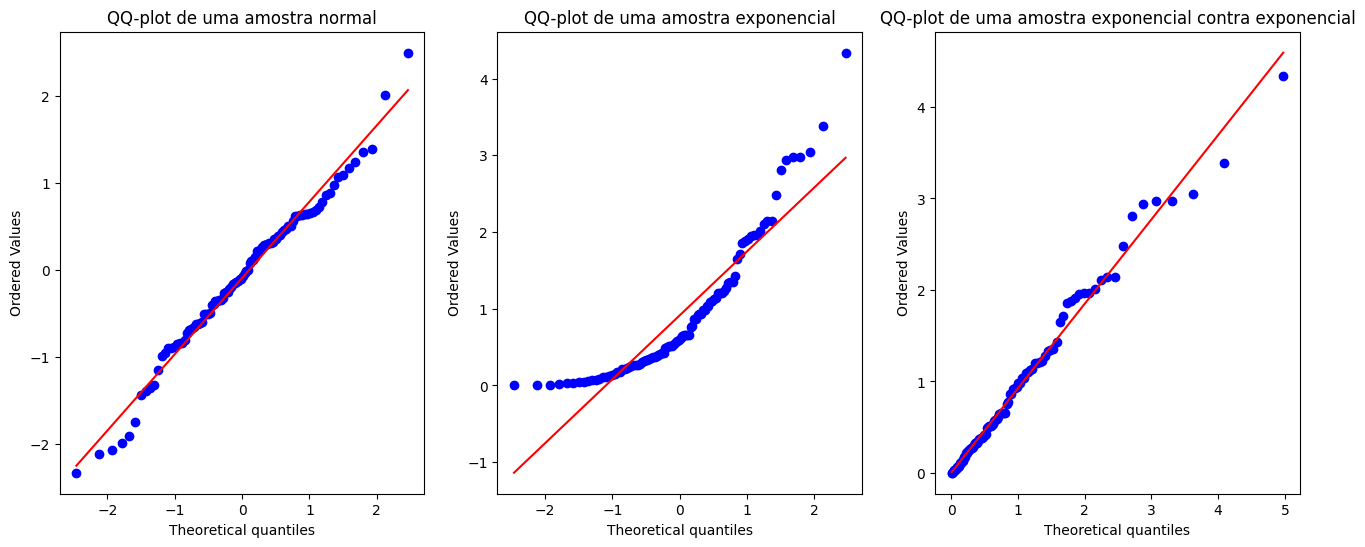

In [ ]:
# QQ-plot
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np


# eixo y: valores ordenados da amostra em d

fig, ax = plt.subplots(1,3, figsize=(16,6))
norm_sample = np.random.normal(loc=0, scale=1, size=100)
stats.probplot(norm_sample, dist="norm", plot=ax[0])
ax[0].set_title("QQ-plot de uma amostra normal")

# outra amostra de outra distribuição
exp_sample = np.random.exponential(scale=1, size=100)
stats.probplot(exp_sample, dist="norm", plot=ax[1])
ax[1].set_title("QQ-plot de uma amostra exponencial")


stats.probplot(exp_sample, dist="expon", plot=ax[2])
ax[2].set_title("QQ-plot de uma amostra exponencial contra exponencial")

plt.show()

## Distribuicoes de cauda longa e cauda pesada

Caudas pesadas, refere-se a distribuições cuja a probabilidade de eventos raros é maior que a mesma em distribuições exponenciais e normais. Em uma distribuição Normal, a probabilidade de um evento extremo cai drasticamente (exponencialmente) conforme você se afasta da média. Na cauda pesada, a probabilidade cai muito mais devagar. (Mais bem distribuido aos arredores)

Exemplo: A distribuição de riqueza. Se o Bill Gates entra em um bar, a "média" de riqueza do bar vai para bilhões. O outlier "pesa" tanto que a média perde o sentido.

Caudas longas, significa que existe uma grande quantidade de eventos que ocorrem com baixa frequência, mas que, quando somados, representam uma parte significativa do todo. É aquela curva que desce e "anda" para a direita por muito tempo, parecendo que nunca vai encostar no zero.

Exemplo: O inventário da Amazon. Existem poucos "best-sellers" (cabeça da curva), mas milhões de livros que vendem apenas 1 cópia por ano (a cauda longa). Somados, esses milhões de livros vendem tanto quanto os best-sellers.

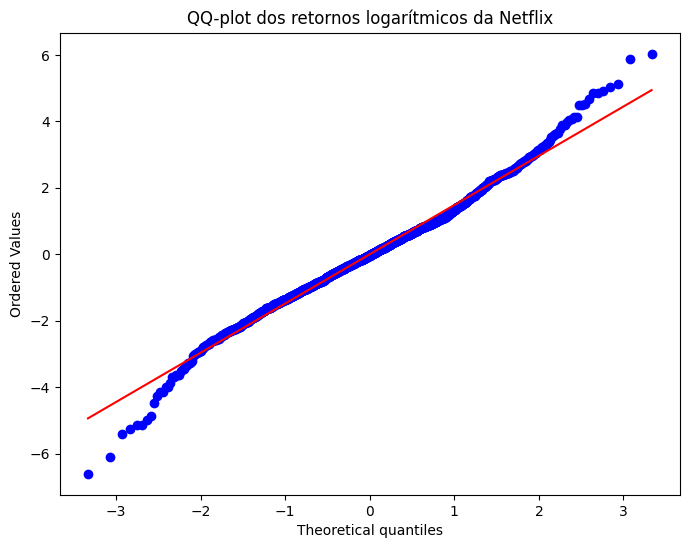

In [ ]:
import pandas as pd

df = pd.read_csv("data_statistics/sp500_data.csv")

netflix = df["NFLX"]
netflix = np.diff(np.log(netflix[netflix > 0]))
fig, ax = plt.subplots(figsize=(8,6))
stats.probplot(netflix, dist="norm", plot=ax)
ax.set_title("QQ-plot dos retornos logarítmicos da Netflix")
plt.show()

## Distribuicao T-student

A distribuicao t-student é uma distribuicao com formato normal (gaussiano) mas um pouco mais grossa no "sino" e com as caudas mais compridas. Como se a t-student, quanto menor o grau de liberdade (tamanho da amostra) distribuice mais as probabilidades entre os valores centrais. isso vem da incerteza que amostras pequenas (menores que 30) geram...

- Formula paramétrica:

$$
IC = \bar{x} \pm t_{\alpha/2, \, n-1} \cdot \frac{s}{\sqrt{n}}
$$

Pode-se ver que quanto maior o n, mais graus de liberdade e consequentemente mais proximo da normal a distribuicao vai estar. Por isso que apara a mostras de tramanho maior que 30 normalmente se usa a distribuicao normal (z-scores). A Student's t-distribution tem caudas mais pesadas do que a normal padrão quando os graus de liberdade são pequenos. Isso significa que ela aloca mais probabilidade nas regiões extremas. Antigamente t-student era muito mais usada pois Imagine que você quer saber a área de um terreno irregular. Hoje, você usaria um GPS e um software. Em 1908, você usaria uma fórmula geométrica que aproximasse o formato do terreno. A Distribuição t é essa "fórmula de aproximação". Distribuição t se tornou o padrão porque ela é muito boa em prever como pequenas amostras se comportam, desde que a estatística que você está medindo tenha o formato de uma Normal (No caso sabemos que a maioria é pelo Teorema central).

- Cientistas de Dados não precisam ser mestres em Distribuição t.

Por que? Porque temos o Bootstrap. Se você tem dúvida sobre a incerteza de um dado, você não precisa de uma fórmula centenária que assume normalidade; você roda uma simulação computacional e obtém uma resposta baseada nos seus dados reais (distribuição empírica).

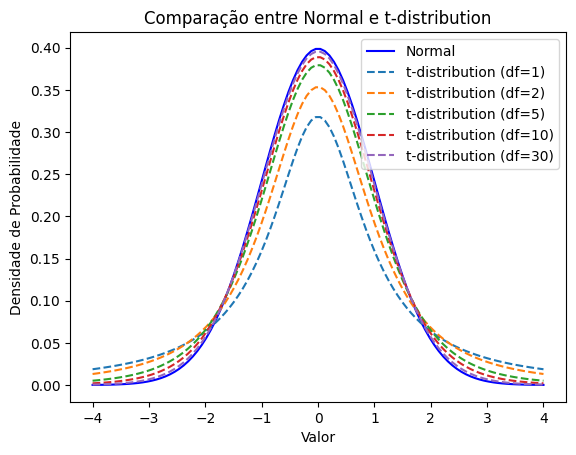

In [ ]:
# Plot normal vs t-distribution para todos os valores de df 
x = np.linspace(-4, 4, 100)
normal_pdf = stats.norm.pdf(x)
plt.plot(x, normal_pdf, label="Normal", color="blue")
for df in [1, 2, 5, 10, 30]:
    t_pdf = stats.t.pdf(x, df=df)
    plt.plot(x, t_pdf, label=f"t-distribution (df={df})", linestyle="--")

plt.title("Comparação entre Normal e t-distribution")
plt.xlabel("Valor")
plt.ylabel("Densidade de Probabilidade")
plt.legend()
plt.show()

## Distribuicao Binomial

É a distribuicao de probabilidade de n experimentos (trials) binários em que o sucesso tem probabilidade p e o fracasso p-1. Por exemplo, jogar a moeda para cima em 10 exprimentos e em cada um temos 50% de chance de ser par ou impar. Ela pode ser util para responder questoes como: Se a probabilidade de um clique converter em venda é 0.02, qual é a probabilidade de observar 0 vendas em 200 cliques? Também pode responder coisas como probabilidade de 2 ou menos sucessos. Com n suficientimente grande e p igual aproximadamente 0.5, temos uma normal.

Probabilidade de exatamente 2: 0.0729
Probabilidade de no máximo 2: 0.9914
Probabilidade de mais de 2: 0.0086
P(2 <= X <= 5): 0.6973


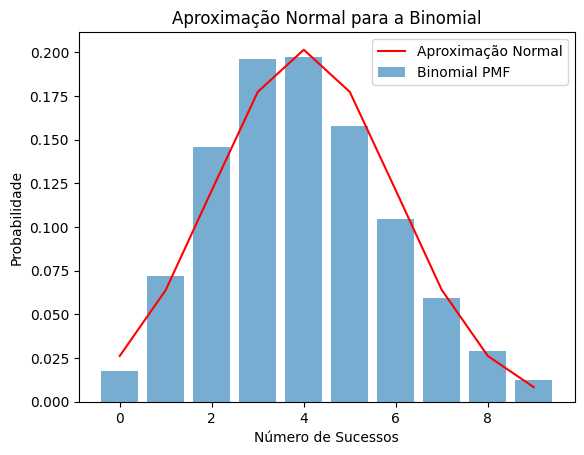

In [ ]:
from scipy.stats import binom

p1 = binom.pmf(k=2, n=5, p=0.1) # 2 sucessos em 5 jogadas, com probabilidade de sucesso de 0.1 em cada jogada
p2 = binom.cdf(2, n=5, p=0.1) # maximo de 2 sucessos em 5 jogadas, com probabilidade de sucesso de 0.1 em cada jogada
p3 = binom.sf(2, n=5, p=0.1) # mais de 2 sucessos em 5 jogadas, com probabilidade de sucesso de 0.1 em cada jogada



print(f"Probabilidade de exatamente 2: {p1:.4f}")
print(f"Probabilidade de no máximo 2: {p2:.4f}")
print(f"Probabilidade de mais de 2: {p3:.4f}")


n = 200
p = 0.02
a = 2
b = 5

prob = binom.cdf(b, n, p) - binom.cdf(a-1, n, p)
print(f"P({a} <= X <= {b}): {prob:.4f}")

# aproximacao normal para a binomial
from scipy.stats import norm
n = 200
p = 0.02

mu = n * p # media da binomial
sigma = np.sqrt(n * p * (1 - p))  # desvio padrão da binomial
x = np.arange(0, 10) # gera valores de 0 a 9 para o número de sucessos

binom_pmf = binom.pmf(x, n, p) # para cada valor de x, calcula a probabilidade de obter exatamente x sucessos em n tentativas com probabilidade p usando a distribuição binomial
normal_approx = norm.pdf(x, mu, sigma) # para cada valor de x, calcula a densidade de probabilidade da distribuição normal com média mu e desvio padrão sigma usando a função de densidade de probabilidade (pdf) da distribuição normal

plt.bar(x, binom_pmf, alpha=0.6, label="Binomial PMF")
plt.plot(x, normal_approx, label="Aproximação Normal", color="red")
plt.title("Aproximação Normal para a Binomial")
plt.xlabel("Número de Sucessos")
plt.ylabel("Probabilidade")
plt.legend()
plt.show()

## Distribuicao Qui-quadrado

Enquanto a distribuicao normal ou t-student focam em medias de valores continuos, a distribuicao qui-quadrado é focada em contagens e categorias (frequencias). Como visto anteriormente ela calcula a frequencia esperada e compara com a observada gerando o valor do qui-quadrado sob a hipotese de independencia das variaveis. Essa estatística serve para ver se um conjunto de dados "se encaixa" em uma distribuição: Imagine que você lança um dado 60 vezes. Você espera que cada número caia 10 vezes. Se o número "6" cair 30 vezes, o Qui-Quadrado vai detectar que esses dados não "se encaixam" na distribuição de um dado honesto. Enquanto um teste A/B comum (t-test) compara duas médias, o Qui-Quadrado é excelente para comparar múltiplos grupos e categorias ao mesmo tempo.

O formato da curva muda dependendo dos Graus de Liberdade, que basicamente dependem de quantas categorias você está comparando ((n_categorias1 - 1) x (n_categorias2 - 1)).
- Com poucas categorias, a curva é muito "esticada" para a esquerda.
- Conforme você aumenta as categorias, a curva começa a parecer mais com uma Normal (mas sempre começando do zero, já que o Qui-Quadrado nunca é negativo).

Diferente da média, que às vezes esconde detalhes, o Qui-Quadrado ajuda a entender associações entre variáveis categóricas.

- Se você quer saber se o "Churn" (cancelamento) de um cliente tem relação com o "Plano" dele, você usará o Qui-Quadrado.
- Se o valor for alto e o p-valor for baixo, você pode dizer: "O plano que o cliente escolhe influencia sim a chance de ele cancelar".

Intuicao da densidade: Se a hipótese nula for verdadeira (ou seja, se os grupos que estou comparando forem idênticos e não houver relação nenhuma entre eles), qual é a chance de eu encontrar um determinado valor de desvio (erro -> Esperado - Observado) ?

- Quanto mais classes temos (graus de liberdade) maior a probabilidade do erro ser mais alto e mais ele se distribui. 

Estatístico Qui-Quadrado: 4.6440
P-valor: 0.0981
Graus de Liberdade: 2


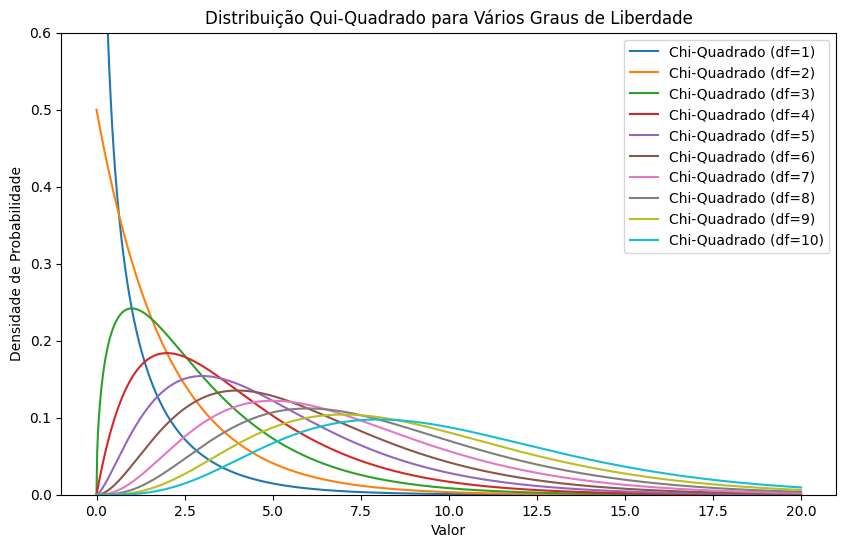

In [ ]:
# Dados Observados (Tabela de Contingência)
# Linhas: Versão A, Versão B, Versão C
# Colunas: Clicou, Não Clicou
observado = np.array([
    [100, 900],  # Versão A (10% de conversão)
    [130, 870],  # Versão B (13% de conversão)
    [110, 890]   # Versão C (11% de conversão)
])

# Teste Qui-Quadrado
# chi2: Esse número é a "distância total" somada de todas as versões em relação ao que seria esperado
# p: O p-valor (a área da cauda à direita do chi2)
# dof: Graus de liberdade ( (3 linhas - 1) * (2 colunas - 1) = 2 )
# esperado: A tabela que seria real se não houvesse diferença entre as cores
chi2, p, dof, esperado = stats.chi2_contingency(observado)

print(f"Estatístico Qui-Quadrado: {chi2:.4f}")
print(f"P-valor: {p:.4f}")
print(f"Graus de Liberdade: {dof}")


# plot de curva de chi2 para varios graus de liberdade
x = np.linspace(0, 20, 1000) # 1000 pontos entre 0 e 20 para o eixo x, que representa os valores da estatística qui-quadrado (amostra de valores de chi2)
plt.figure(figsize=(10, 6))

for df in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    chi2_pdf = stats.chi2.pdf(x, df) # para cada valor de df, calcula a densidade de probabilidade da distribuição qui-quadrado usando a função de densidade de probabilidade (pdf) da distribuição qui-quadrado, e plota a curva correspondente no gráfico
    plt.plot(x, chi2_pdf, label=f"Chi-Quadrado (df={df})")

plt.ylim(0, 0.6) 

plt.title("Distribuição Qui-Quadrado para Vários Graus de Liberdade")
plt.xlabel("Valor")
plt.ylabel("Densidade de Probabilidade")
plt.legend()
plt.show()

## F-Distribution

É uma distribuicao util para testar varios tratamentos em multiplos grupos (por exemplo, diferentes fertilizantes em diferentes blocos de terra). isso é semelhante com teste A/B/C, mostrado anteriormente mas dessa vez esta lidando com variaveis continuas ao inves de contagens. Se qui-quadrado era contar coisas, F é para medir coisas...em poucas palavras F é a variabilidade entre grupos divida pela variabilidade dentro dos grupos e vai de 1 a infinito. Hipotese nula de que a media de todos os grupos sao iguais.

Imagine que você está testando 3 tipos de fertilizantes (A, B e C) em várias plantas:

- Variabilidade ENTRE grupos: É a diferença entre as médias de produção de cada fertilizante. (O quanto as médias "pulam" de uma para a outra).
- Variabilidade DENTRO dos grupos (Residual): É a variação natural entre plantas que usaram o mesmo fertilizante. (O "ruído" ou erro natural dentro dos grupos).

O que o valor de F nos diz?

- F próximo de 1: A variação entre os grupos é igual à variação natural. Conclusão: Os fertilizantes são todos iguais, o que você vê é só barulho.
- F muito maior que 1: A diferença entre as médias dos fertilizantes é muito maior do que o ruído natural das plantas. Conclusão: Pelo menos um fertilizante faz diferença real!

Intuicao da densidade: Se a hipótese nula for verdadeira (ou seja, se os fertilizantes/tratamentos forem todos iguais e não houver efeito nenhum), qual é a chance de a diferença entre as médias dos grupos ser X vezes maior que a variação natural dentro dos grupos?   

Quanto mais grupos/classes (Grau de Liberdade do Numerador) você compara (ex: testar 10 fertilizantes em vez de apenas 2):

- Mais "chances" de erro: Assim como na Qui-Quadrado, você tem mais grupos para "pular" longe da média global por puro azar.

- A curva se achata: O valor de F esperado para o puro acaso começa a se deslocar, e a curva ganha uma "barriga" mais larga.

Quanto mais plantas você mede dentro de cada grupo (aumentando o tamanho da amostra -> Grau de Liberdade do Denominador):

- O "Ruído" fica mais preciso: Você tem muito mais certeza de qual é a "variação natural" do seu sistema.

- A curva fica "comportada": Com muitos dados, a distribuição F fica mais estreita e "pontiaguda". O valor de F esperado pelo acaso se estabiliza fortemente ao redor de 1.


Estatística F: 4.8862
P-valor: 0.0154


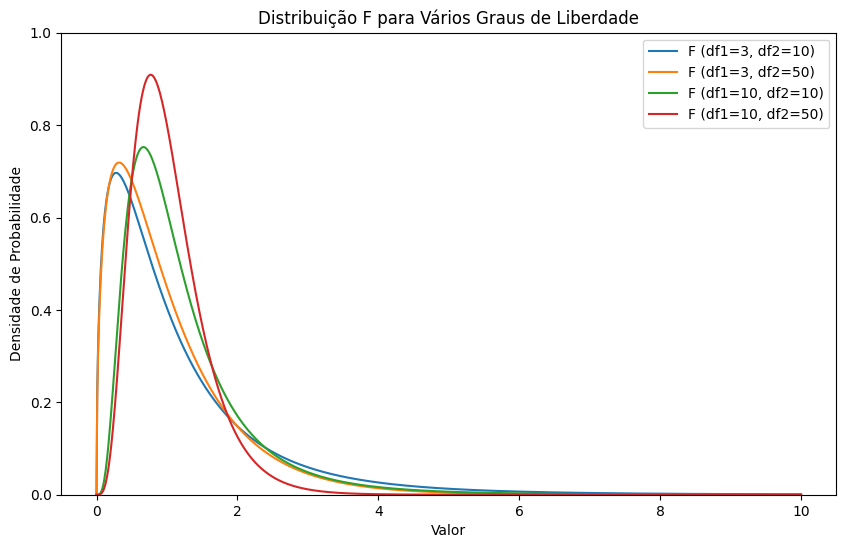

In [ ]:

# peso da colheita (em gramas) para cada grupo
np.random.seed(42)
fert_A = np.random.normal(50, 5, 10)  # Média 50g
fert_B = np.random.normal(60, 5, 10)  # Média 60g (O melhor!)
fert_C = np.random.normal(52, 5, 10)  # Média 52g

# f_stat: A razão entre a variância entre grupos e dentro dos grupos
# p_val: A probabilidade de esse F acontecer por acaso
f_stat, p_val = stats.f_oneway(fert_A, fert_B, fert_C)

print(f"Estatística F: {f_stat:.4f}")
print(f"P-valor: {p_val:.4f}")

# plot de curva de F para varios graus de liberdade
x = np.linspace(0, 10, 1000) # 1000 pontos entre 0 e 10 para o eixo x, que representa os valores da estatística F (amostra de valores de F)
plt.figure(figsize=(10, 6))

for df1 in [3, 10]: # graus de liberdade do numerador (entre grupos)
    for df2 in [10, 50]: # graus de liberdade do denominador (dentro dos grupos)
        f_pdf = stats.f.pdf(x, df1, df2) # para cada combinação de df1 e df2, calcula a densidade de probabilidade da distribuição F usando a função de densidade de probabilidade (pdf) da distribuição F, e plota a curva correspondente no gráfico
        plt.plot(x, f_pdf, label=f"F (df1={df1}, df2={df2})")

plt.ylim(0, 1)
plt.title("Distribuição F para Vários Graus de Liberdade")
plt.xlabel("Valor")
plt.ylabel("Densidade de Probabilidade")
plt.legend()
plt.show()


## Poison, Exponencial e Weibull

- Poisson:

    Modela probabilidade de k eventos em um intervalo de tempo ou espaco baseado em uma estimativa lambda que é a media de acontecimentos por intervalo. Util para responder perguntas como: 

    - "Um servidor recebe, em média, 5 solicitações de acesso por minuto. Qual a probabilidade de o servidor receber exatamente 8 solicitações no próximo minuto?"
    - "Em uma linha de produção de tecidos, ocorrem em média 2 defeitos a cada 100 metros. Qual a chance de encontrarmos um rolo de 100 metros sem nenhum defeito?"
    - "Uma loja de conveniência recebe 12 clientes por hora durante a madrugada. Qual a probabilidade de chegarem mais de 20 clientes em uma hora específica?"

    $$
    P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}
    $$

- Exponencial:

    Modela probabilidade do tempo x até ocorrencia do proximo evento em um processo baseado em uma estimativa lambda que é a media de tempo. Util para responder perguntas como: 

    - "O tempo de vida de uma lâmpada de LED segue uma distribuição exponencial com média de 8.000 horas. Qual a probabilidade de uma lâmpada queimar antes de completar 1.000 horas de uso?"
    - "O tempo entre a chegada de navios em um porto é exponencial com média de 12 horas. Se um navio acabou de atracar, qual a probabilidade de o próximo navio chegar apenas daqui a 24 horas ou mais?"
    - "O intervalo entre tentativas de ataques de força bruta em um firewall segue uma distribuição exponencial com média de 10 segundos. Qual a probabilidade de ocorrer um novo ataque em menos de 2 segundos após o último?"

    $$
    f(x) = \lambda e^{-\lambda x}, \quad x \ge 0
    $$

- Problema de estimacao da media:

    Existem eventos muito raros e portanto poucos dados sobre eles (falha de motor de avioes). Entao temos poucos casos para estimar o tempo entre ocorrencias... poreme existem alguns chutes: Se um evento nao acontece a muuuito anos entao podemos ter certeza que a media de ocorrencia é maior que 1, pode ser feitos simulacoes ou calculos hipoteticos. Se existe dados mas sao poucos podemos usar o chi-square test para testar varias estimativas e ver qual casa melhor com os dados que temos.

- Weibull:

    Existem casos em que a media de eventos por tempo nao é fixa, ou seja, ela aumenta ou reduz com o tempo. Weibull é uma extensao da exponencial que adiciona um parametro *B(ou k)* em que se B>1 a probabilidade do evento aumenta com o tempo e se B<1 a probabilidade reduz com o tempo e um parametro n que define uma escala temporal daquele evento (vida caracteristica, ou tempo de vida comum). Modela o tempo de vida ou o tempo até a falha de um objeto ou sistema. O grande diferencial dela é que ela consegue descrever se um produto falha mais no começo (defeito de fábrica), de forma constante (acidente) ou no final (desgaste).

    - Se muitos aparelhos falham nas primeiras 48 horas devido a problemas de solda, a curva de Weibull ajuda a empresa a decidir por quanto tempo o produto deve ser testado na fábrica antes de ser enviado às lojas (o chamado burn-in)
    - Modelando o tempo até o surgimento de rachaduras com B>1 (geralmente entre 2 e 3), os engenheiros conseguem prever exatamente em qual ano a probabilidade de falha será alta demais, permitindo trocar a pá antes que ela quebre e destrua a turbina
    - Em testes de novos medicamentos contra o câncer, os pesquisadores usam a Weibull para descrever a probabilidade de um paciente permanecer livre da doença ao longo dos meses. Se a droga funciona bem, o parâmetro de escala da distribuição "empurra" a curva de sobrevivência para a direita, indicando uma vida mais longa.

    $$
    f(x) = 
    \frac{k}{\lambda}
    \left( \frac{x}{\lambda} \right)^{k-1}
    e^{-(x/\lambda)^k},
    \quad x \ge 0
    $$

In [ ]:
from scipy.stats import poisson, expon

# Poisson 

# simulando o número de eventos (ex: chamadas em um call center) em um intervalo de tempo, onde a média é 5 eventos por hora
poisson_sample = poisson.rvs(5, size=10) # cada valor representa o número de chamadas em uma hora, e a média desses valores deve ser aproximadamente 5, refletindo a média da distribuição Poisson que estamos simulando.
print("Alguns valores simulados da distribuição Poisson (média = 5):")
print(poisson_sample)

# Exponencial

# simulando o tempo entre eventos (ex: tempo entre chamadas em um call center) onde a média é 1 hora
expon_sample = expon.rvs(scale=1, size=10) # representa o tempo entre chamadas, e a média desses valores deve ser aproximadamente 1 hora, refletindo a média da distribuição Exponencial que estamos simulando. O parâmetro scale=1 indica que a média da distribuição é 1, ou seja, o tempo médio entre eventos é de 1 hora.
print("\nAlguns valores simulados da distribuição Exponencial (média = 1 hora):")
print(expon_sample)

# Weibull

# simulando o tempo até a falha de um componente, onde a forma é 1.5 e a escala é 1000 horas
weibull_sample = stats.weibull_min.rvs(1.5, scale=1000, size=10) # cada valor representa o tempo até a falha de um componente, e a média desses valores deve ser aproximadamente 1000 horas, refletindo a escala da distribuição Weibull que estamos simulando. O parâmetro c=1.5 indica a forma da distribuição, onde valores menores que 1 indicam uma taxa de falha decrescente ao longo do tempo, valores iguais a 1 indicam uma taxa de falha constante, e valores maiores que 1 indicam uma taxa de falha crescente ao longo do tempo.
print("\nAlguns valores simulados da distribuição Weibull (forma = 1.5, escala = 1000 horas):")
print(weibull_sample)





Alguns valores simulados da distribuição Poisson (média = 5):
[4 6 7 2 5 5 6 4 6 6]

Alguns valores simulados da distribuição Exponencial (média = 1 hora):
[0.11416744 0.03193368 1.01172955 0.37739671 0.71043718 2.38126553
 0.28673882 0.52828197 1.40874915 0.25980516]

Alguns valores simulados da distribuição Weibull (forma = 1.5, escala = 1000 horas):
[ 185.8248577   489.18089939  313.82895643 1917.36254968 1396.83436992
 1002.32810585 1614.54615775 1383.87674039  349.36041495 1707.29602966]
